Purpose: URL is Legitimate or Phising?

In [170]:
#Import necessary libraries with aliases
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [171]:
df = pd.read_csv("PhiUSIIL_Phishing_URL_Dataset.csv")

Firstly, To understand what a dataset is, we first need to understand what columns mean. For this purpose, we created the following dictionary table.

In [172]:
df_data_dict = pd.read_csv("column_explanations.csv")

# Column Explanations as Data Dictionary
data_dict = pd.DataFrame(df.dtypes, columns=['Data Type'])

# Column names
data_dict = data_dict.reset_index().rename(columns={'index': 'Feature Name'})

# 3. First rows values for each column as an example of the values
data_dict['Example'] = df.iloc[0].values

# Explanations from csv file
data_dict['Explanation'] = df_data_dict['english_description']

# Display table
display(data_dict)

,Feature Name,Data Type,Example,Explanation
0,FILENAME,object,521848.txt,Name of the file (can be ignored).
1,URL,object,https://www.southbankmosaics.com,The full URL being analyzed.
2,URLLength,int64,31,Total character length of the URL.
3,Domain,object,www.southbankmosaics.com,"The domain name (e.g., google.com)."
4,DomainLength,int64,24,Character length of the domain name.
5,IsDomainIP,int64,0,Checks if the domain is an IP address (0/1).
6,TLD,object,com,"Top-Level Domain (e.g., .com, .net, .org)."
7,URLSimilarityIndex,float64,100.0,Similarity index with known legitimate sites.
8,CharContinuationRate,float64,1.0,Rate of continuing characters (pattern repetit...
9,TLDLegitimateProb,float64,0.522907,Probability of the TLD being legitimate.


In [173]:
df.shape

(235795, 56)

Comment: We have 55 features and 1 target variable. Data has 234795 number of URL.

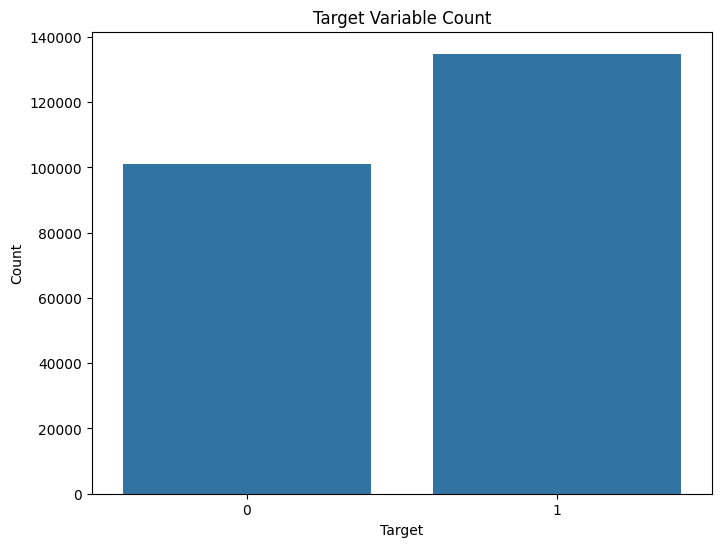

In [174]:
#Looking number of target variables. This is important for our problem. In real life most of the URL's are legitimate. 
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x=df["label"])
plt.xlabel('Target')
plt.ylabel('Count')
plt.title('Target Variable Count')
plt.show()

Comment: We see that the target variable counts are close to each other. But as in real life scenario 0 (phising url) count is less than legitimate values. This dataset can gives us more information about phising urls. 

In [175]:
df.head()

,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,...,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,...,1,0,1,244,15,34,72,1,85,1


Comments: Data looks like clean, and most of features comes from the URL. Label is our target variable. We have lots of binary variables in raw dataset. TLD is categorical variable, and it seems we can group them. Firsly, we want to look at the correlation matrix in order to look at the which features have most effect on target variable. 

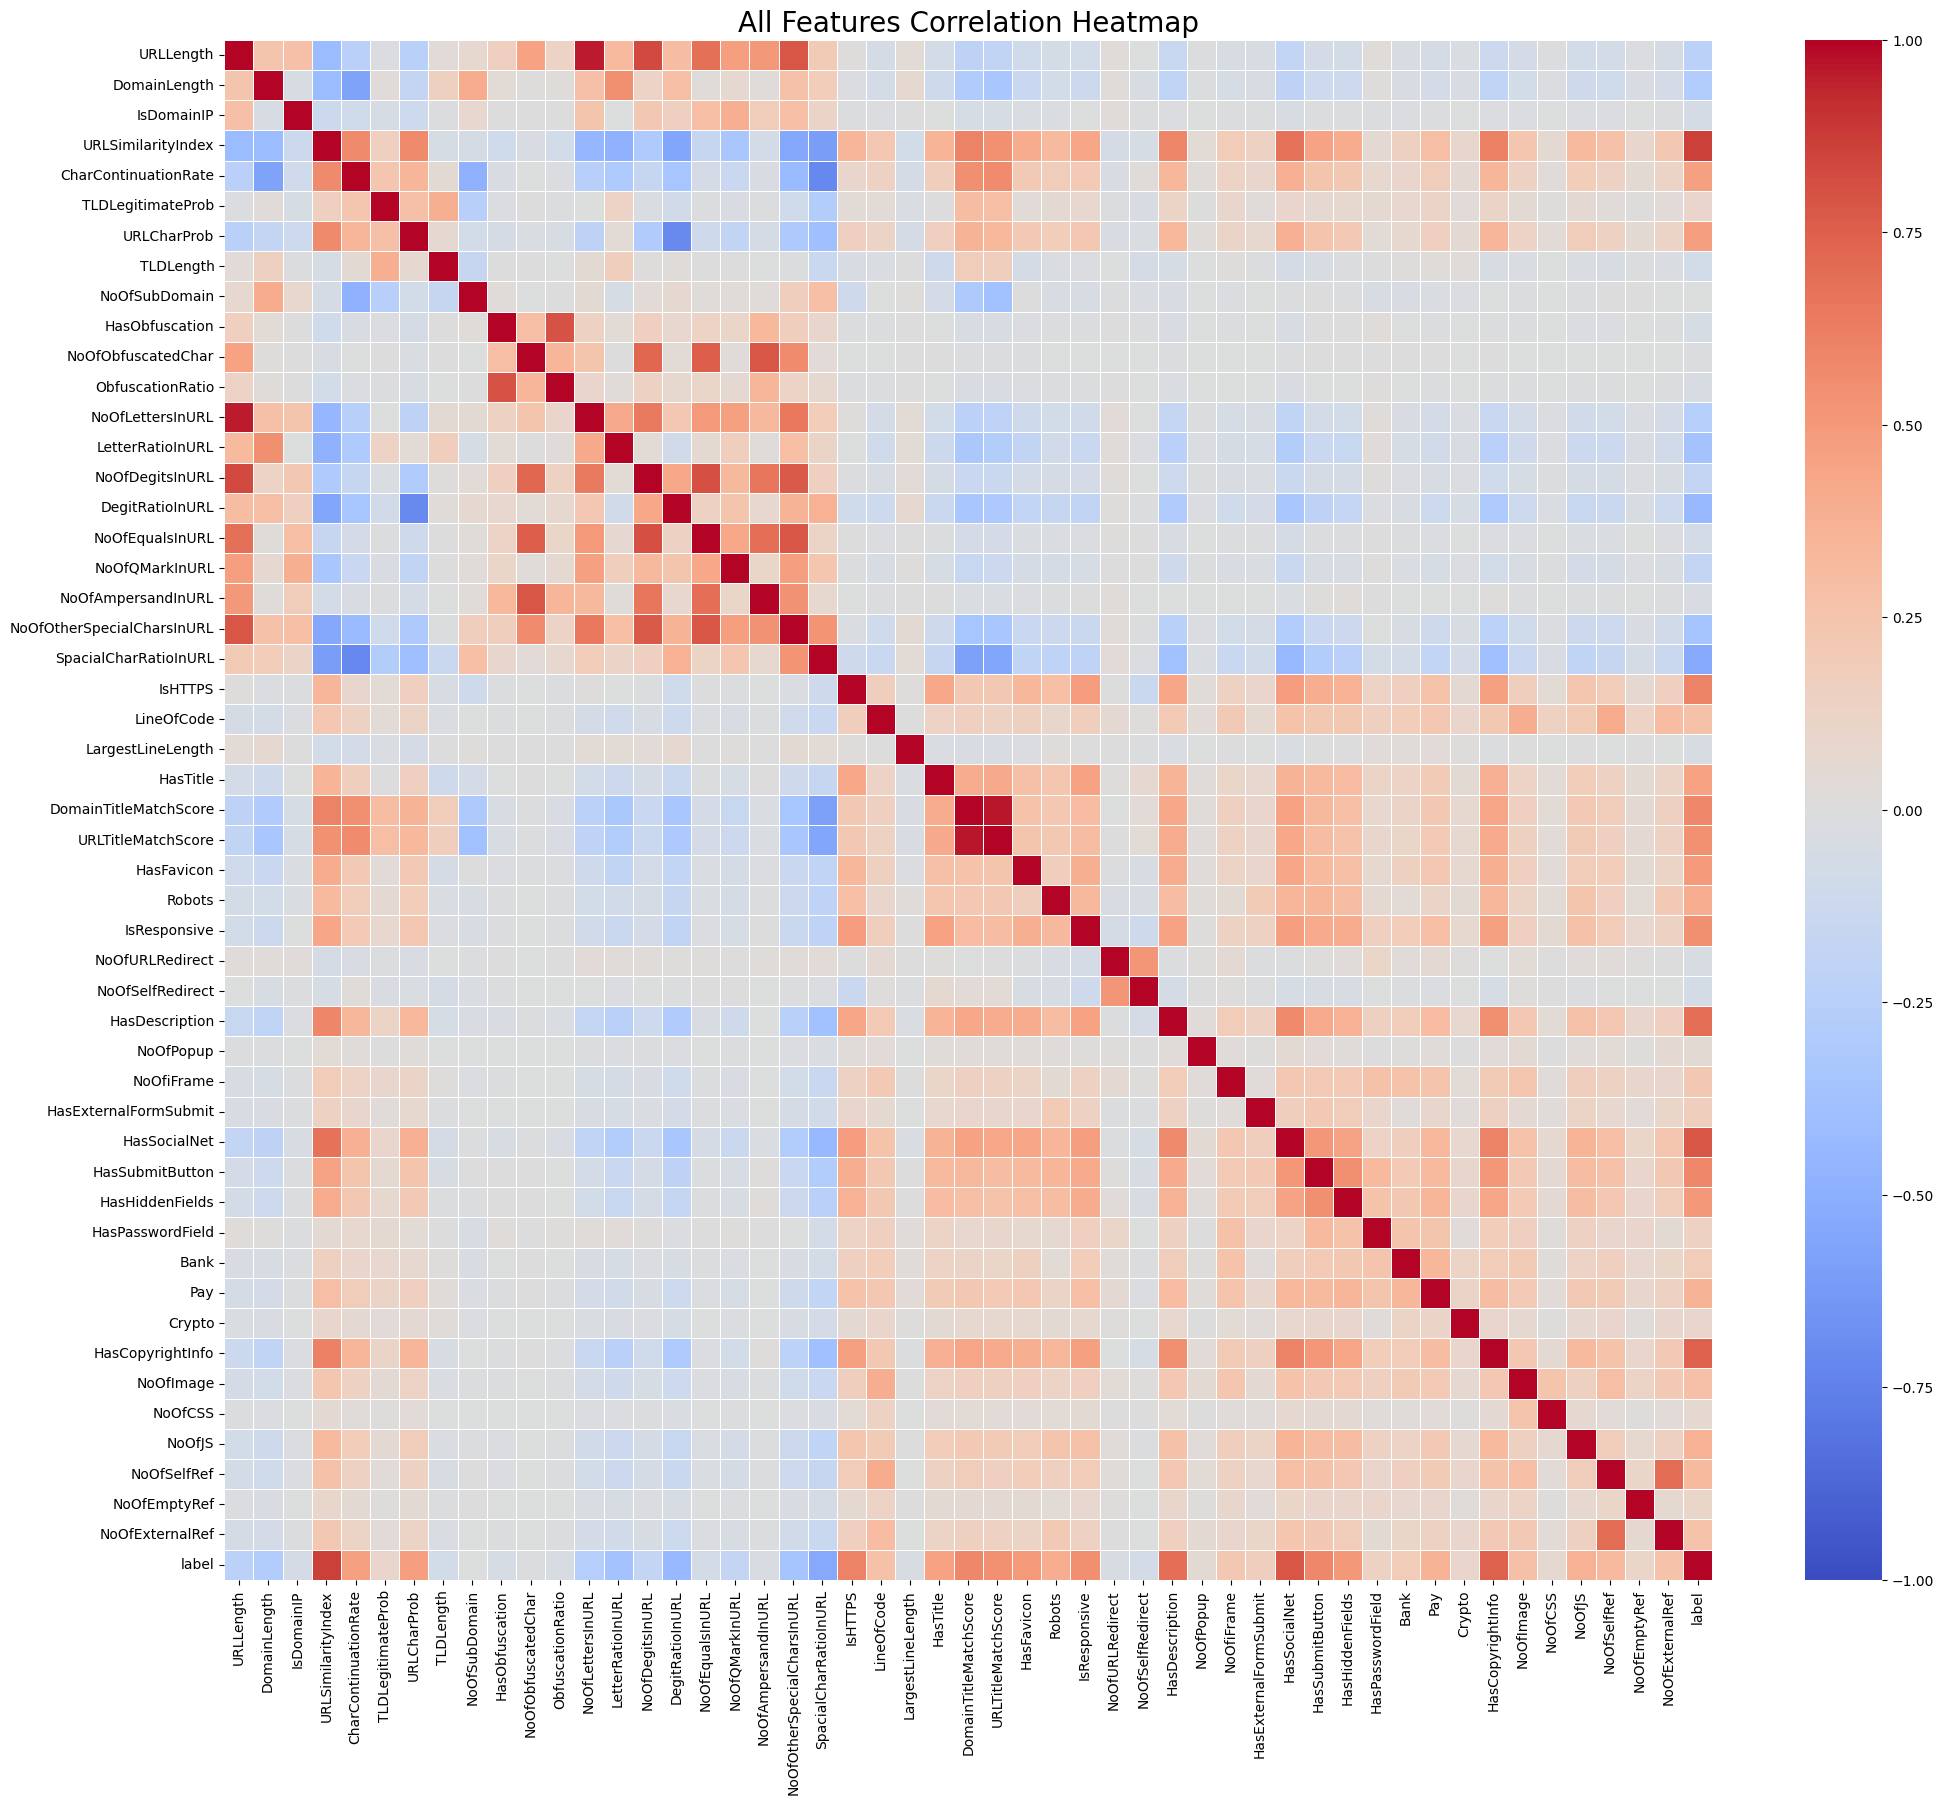

In [176]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(24, 20)) 
sns.heatmap(corr_matrix, 
            annot=False,      
            cmap='coolwarm',  # (Red: Positive, Blue: Negative)
            linewidths=0.5,   
            vmin=-1, vmax=1)

plt.title('All Features Correlation Heatmap', fontsize=20)
plt.show()

Comments: Strong correlation between features can be handle in feature enginerring part. Firstly, we want to look at closely on which features have effect on our target variable. We see this information on heatmap but we want to look closely.  

C:\Users\ASUS\AppData\Local\Temp\ipykernel_6188\2732559188.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_corr.values, y=target_corr.index, palette=colors)


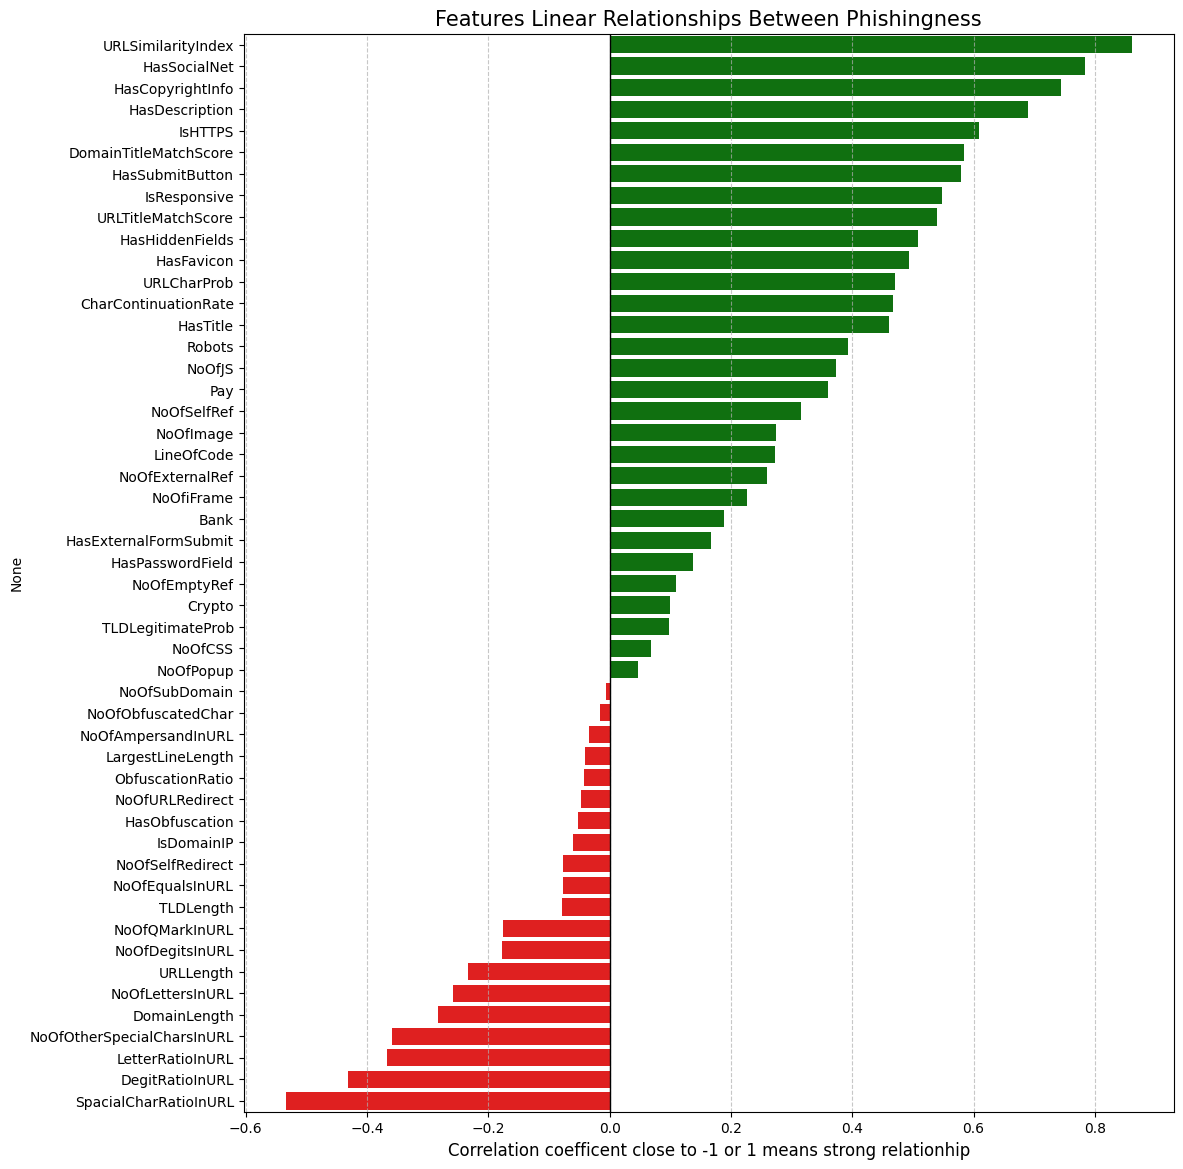

In [177]:
target_corr = numeric_df.corr()['label'].sort_values(ascending=False)
target_corr = target_corr.drop('label')
plt.figure(figsize=(12, 14))
colors = ['green' if x > 0 else 'red' for x in target_corr.values] # (Green:Positive, Red: Negative)
sns.barplot(x=target_corr.values, y=target_corr.index, palette=colors)

plt.title('Features Linear Relationships Between Phishingness', fontsize=15)
plt.xlabel('Correlation coefficent close to -1 or 1 means strong relationhip', fontsize=12)
plt.axvline(0, color='black', linewidth=1) # Black line in the middle
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Comment: Features that are close to 0 correlation coefficents indicates pottential features that we must deal with maybe we extract these from the model because they have not strong effect on target variable and adds complexity for our model. Strong relationships can be our focus features in the analysis. 

We examine that the some float and integer data types are binary variables. Firstly, we can seperate these variables and then we can see the the selected features which are seem more correlated with our target variable.

In [178]:
#All features with numeric data types
numeric_df = df.select_dtypes(include=['float64', 'int64'])

#Features have exactly 2 unique variables
binary_cols = [col for col in numeric_df.columns if numeric_df[col].nunique() == 2]

#Features have more than 2 unique variables are not binary
continuous_cols = [col for col in numeric_df.columns if numeric_df[col].nunique() > 2]

print(f"Binary Feature Number: {len(binary_cols)}")
print(f"Continous Feature Number: {len(continuous_cols)}")

Binary Feature Number: 20
Continous Feature Number: 31
